# Flood analysis using WASDI Earth observation flooding datasets
## 1.1. Introduction: Flood analysis and road risk map
Earth observation (EO) techniques provied a powerful means of monitoring and mapping disaster-related events, such as **floods**, offering invaluable support that would be difficult to obtain through ground-based observations alone, especially in inaccessible areas following a disaster. 
The **[WASDI platform](https://www.wasdi.cloud/)** represents a significant advancement in Earth observation data processing, enabling effective flood monitoring. This notebook's purpose is to analyse flood events with WASDI data, and retrieve further information about a specific flood event. This specific use case, uses WASDI data from related to the flood events that took place in **St Polten in Vienna, in 2024**. You cand read more about this story on [RACE platform](race.esa.int).

<img src="https://ichef.bbci.co.uk/ace/standard/1024/cpsprodpb/3cd2/live/cfdfa030-734d-11ef-b282-4535eb84fe4b.jpg" alt="title" width="700"/>

## 1.2. Objective of this notebook:
Based on these events, this notebooks aims at analize the **temporal progression of flooded areas**, and generate a **road risk** based on the **most flooded date** and generated images and interactive map of it:

![Title](FLOODS/header.png)


## 1.3 Input data

#### WASDI platform and NoR
[WASDI is a cloud-based workspace](https://www.wasdi.cloud/) designed to simplify the access, processing, and analysis of satellite data for environmental applications, including flood management. The method used to produce flood maps over open area is integrated in an app named SAR Flood Archive Generator 3.3.4. It is an automated application designed to process the [Copernicus Sentinel-1 GRD](https://dataspace.copernicus.eu/explore-data/data-collections/sentinel-data/sentinel-1) archive for a specified Area of Interest (AoI), compiling historical flood maps in open areas. You can find more information about [WASDI on their dedicated website](https://wasdi.readthedocs.io/en/latest/GettingStarted/WasdiTutorial.html) and request access to it thorugh the [ESA Network of Resource (NoR)](https://nor-discover.org/). NoR is an ESA initiative to facilitate the use of cloud environments by users, and it has a [sponsorhip call](https://eo4society.esa.int/network-of-resources/nor-sponsorship/), aiming to support research, development and pree-commerical users. 
- Flood maps with **2 classes** (flood + land) or **3 classes** (flood + land + permanent water).
- Format: TIF
- Dataset size: 23 dates (from 17-07-2024 to 22-09-2024)
- Areao of Interest (AOI): St Polten, Vienna, Austria

## 1.4 Import libraries

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
from datetime import datetime 
import re  
import numpy as np
import rasterio as rio
import folium
from matplotlib import pyplot as plt
import folium 
from folium import raster_layers
from folium.elements import MacroElement
from jinja2 import Template
from pyproj import Transformer
from IPython.display import IFrame
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.plot import show
from rasterio.enums import Resampling as ResampleMethod
from matplotlib.patches import Patch
from osgeo import gdal
#!pip install osmnx
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject
from rasterio.enums import Resampling as ResampleMethod
from matplotlib.patches import Patch
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.features import rasterize
from shapely.geometry import mapping

from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
import numpy as np

## 1.5 Defining working folders

In [2]:
# Folder path containing all the images and converts it to a string. 
folder_path = str('/home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/FLOODS/')

# Creates a list with all path images that end with .tif
tif_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('flood.tif')]
print('Printing first file to check if paths are correct:')
print(tif_files[0:1])

# Location where to save the animation/GIF created on step 4. 
PATH = str('/home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/')


output_floods = "output"
floods_path = os.path.join(os.getcwd(), "Floods Output Results", output_floods)

# Create output dir
os.makedirs(floods_path, exist_ok=True)

Printing first file to check if paths are correct:
['/home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/FLOODS/StPoltenVienna_2024-08-27_flood.tif']


# 2. Dataset Inspection
This step involves an initial exploration of the dataset to identify its key characteristics.  

## 2.1. Images analysis
The inspection focuses on determining essential information, including:  
- The total number of images in the dataset  
- The dimensions of each image (height × width)  
- The data type of the images  
- The number of classes or distinct pixel values present  

This analysis is particularly relevant for the WASDI dataset, which may contain either 2 or 3 classes. Understanding these attributes is critical for subsequent data processing and analysis.

In [3]:
print('There is a total of ' + str(len(tif_files)) + ' WASDI files')

# Removes max image pixel limit
Image.MAX_IMAGE_PIXELS = None

if tif_files:
    # Open the first image
    img = Image.open(tif_files[6])
    
    # Converts it to an array 
    img_array = np.array(img)

    # Prints its basic information
    print(f"Each file has the shape: {img_array.shape}")
    print(f"The files data type is: {img_array.dtype}")
    # print(f"Min pixel value: {img_array.min()}")
    # print(f"Max pixel value: {img_array.max()}")

    # Prints unique pixel values existing in the image
    if img_array.ndim == 2:
        # Single band (grayscale)
        unique_values = np.unique(img_array)
        print(f"Unique pixel values: {unique_values}")
    else:
        # Multi-band (e.g. RGB or multispectral)
        for i in range(img_array.shape[-1]):
            band_unique = np.unique(img_array[..., i])
            print(f"Band {i+1} unique pixel values: {band_unique}")

else:
    print("No .tif files found.")

There is a total of 8 WASDI files
Each file has the shape: (11132, 11132)
The files data type is: uint8
Unique pixel values: [0 1 2 3]


### 2.2 Visual Inspection of the Files
Plot one of the images to to visually inspect the dataset.

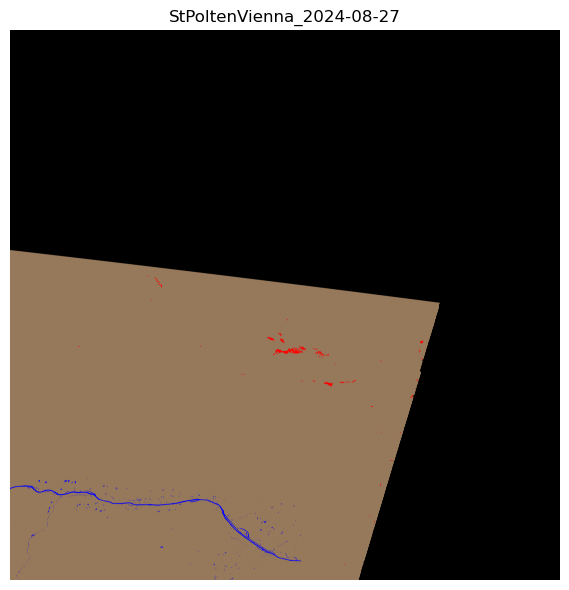

In [4]:
no_flood_files = []  # List to store files without flood (value 3)

# Loop through each file of the dataset
for i, file in enumerate(tif_files):
    img = Image.open(file)
    img_array = np.array(img)

    # Create an RGB image initialized to black
    color_img = np.zeros((*img_array.shape, 3), dtype=np.uint8)

    # Assign colors based on class values
    color_img[img_array == 1] = [150, 120, 90]  # grey brown land
    color_img[img_array == 2] = [0, 0, 255]     # blue perm water
    color_img[img_array == 3] = [255, 0, 0]     # red flood

    # Plot the image
    plt.figure(figsize=(6, 6))
    plt.imshow(color_img)
    plt.title(os.path.basename(file)[0:-10])
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    break  # stop at first image


# 3. Analising flooded areas

## 3.1. Estimating flooded areas (m2) and most flooded date
To estimate the flooded areas, we assume that each pixel is **10m2** (since these datasets are based on Sentinel-1 image)). 

We count the number of pixels of class 3, which from above we could understand it corresponds to flooded areas so:
- flooded: **pixel red, value = 3)**
- permanent water: **pixel blue, value =2)**

In [5]:
# Pixel resolution in square meters
pixel_area = 10  
print("Printing first 3 images estimations...")
print(" ")
# Loop through 3 first images and compute areas of flood and permament water
for file in tif_files[:3]:
    # Open image
    img = Image.open(file)
    
    # Convert to NumPy array
    img_array = np.array(img)

    # Count pixels for each category
    permWater_pixels = np.sum(img_array == 2)
    flood_pixels = np.sum(img_array == 3)

    # Calculate total areas
    permWater_area = permWater_pixels * pixel_area
    flood_area = flood_pixels * pixel_area

    # Print results
    print(f"Image: {os.path.basename(file)}")
    print(f"  Permanent Water area: {permWater_area} m²")
    print(f"  Flooded area: {flood_area} m²")
    print("-" * 30)

Printing first 3 images estimations...
 
Image: StPoltenVienna_2024-08-27_flood.tif
  Permanent Water area: 2042060 m²
  Flooded area: 838130 m²
------------------------------
Image: StPoltenVienna_2024-09-08_flood.tif
  Permanent Water area: 2040270 m²
  Flooded area: 434800 m²
------------------------------
Image: StPoltenVienna_2024-08-30_flood.tif
  Permanent Water area: 2039470 m²
  Flooded area: 14430 m²
------------------------------


## 3.2. Plotting temporal progression of floods
Plots flooded and permament water areas by date and prints the top three days with largest flooded areas.

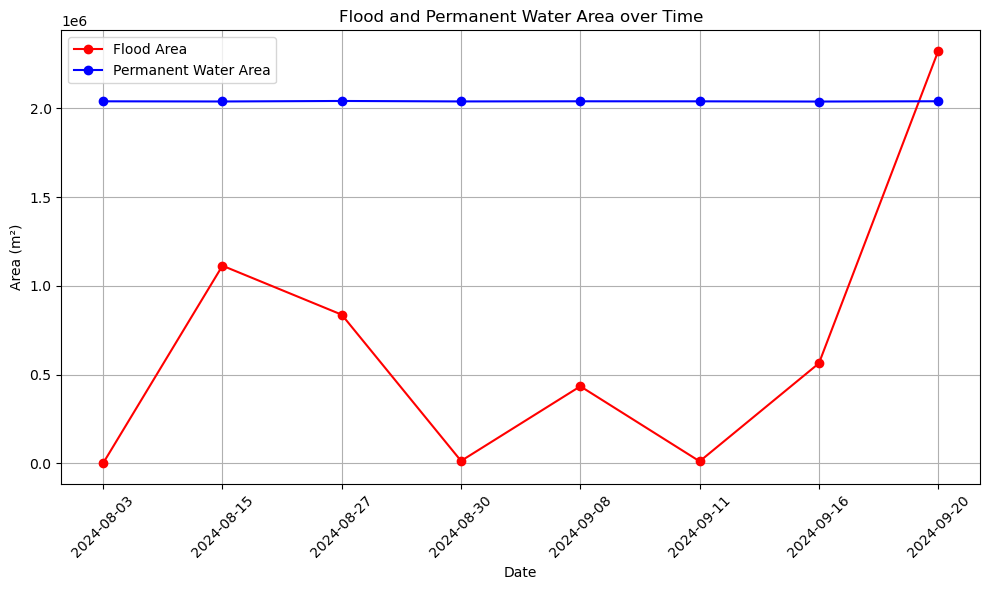

Plot saved to: /home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/Floods Output Results/output/Temporal evolution of flooded and permanent water areas.png
The 3 Most Flooded Days:
- 2024-09-20: 2,323,890.00 m²
- 2024-08-15: 1,114,080.00 m²
- 2024-08-27: 838,130.00 m²
Most flooded file: /home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/FLOODS/StPoltenVienna_2024-09-20_flood.tif


In [6]:
# Initialize data lists
dates = []
flood_areas = []
permWater_areas = []

# Loop through each image to compute flood and permanent water areas
for file in tif_files:
    # Open image and convert to NumPy array
    img = Image.open(file)
    img_array = np.array(img)

    # Count class pixels
    flood_pixels = np.sum(img_array == 3)
    permWater_pixels = np.sum(img_array == 2)

    # Calculate area in m²
    flood_area = flood_pixels * pixel_area
    permWater_area = permWater_pixels * pixel_area

    # Extract date from filename (format: YYYY-MM-DD)
    date_match = re.search(r'(\d{4}-\d{2}-\d{2})', os.path.basename(file))
    if date_match:
        date_str = date_match.group(1)
        dates.append(date_str)
        flood_areas.append(flood_area)
        permWater_areas.append(permWater_area)
    else:
        print(f"Date not found in filename: {os.path.basename(file)}")

# Sort data by date
sorted_data = sorted(zip(dates, flood_areas, permWater_areas), key=lambda x: datetime.strptime(x[0], "%Y-%m-%d"))
dates, flood_areas, permWater_areas = zip(*sorted_data)

# Plot flood and permanent water areas over time
plt.figure(figsize=(10, 6))
plt.plot(dates, flood_areas, marker='o', linestyle='-', color='r', label="Flood Area")
plt.plot(dates, permWater_areas, marker='o', linestyle='-', color='b', label="Permanent Water Area")

plt.xlabel("Date")
plt.ylabel("Area (m²)")
plt.title("Flood and Permanent Water Area over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

# Save plot to output folder
output_plot_path = os.path.join(floods_path, "Temporal evolution of flooded and permanent water areas.png")
plt.tight_layout()
plt.savefig(output_plot_path, dpi=300)
plt.show()

print(f"Plot saved to: {output_plot_path}")

# Print top 3 most flooded days
top_floods = sorted(zip(dates, flood_areas), key=lambda x: x[1], reverse=True)[:3]
print("The 3 Most Flooded Days:")
for date, area in top_floods:
    print(f"- {date}: {area:,.2f} m²")

# Get the date of the most flooded day
most_flooded_date = top_floods[0][0]

# Find the file corresponding to that date
most_flooded_file = None
for file in tif_files:
    if most_flooded_date in os.path.basename(file):
        most_flooded_file = file
        break

print(f"Most flooded file: {most_flooded_file}")


## 3.3. Visualize most flooded date over a true color image
Plots a onverlay of the most flooded date, over a Sentinel-2 image - and exports it.

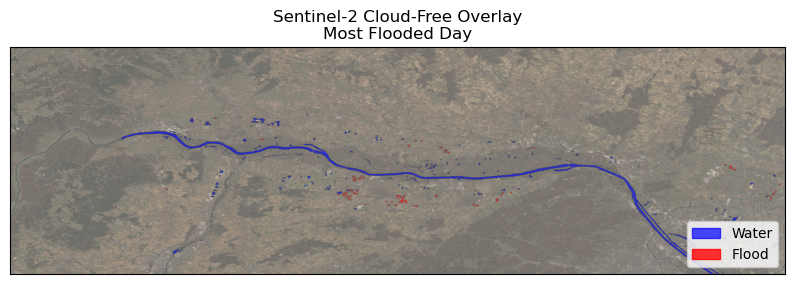

Most flooded date file: /home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/StPoltenVienna_2024-09-20_flood.tif
Image saved to: /home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/Floods Output Results/output/sentinel2_flood_overlay_most_flooded.png


In [7]:
folder_path = str(os.getcwd())
# Sentinel-2 base image 
base_tif_path = os.path.join(folder_path, "2025-03-20-00_00_2025-03-20-23_59_Sentinel-2_L2A_True_color (1).tiff")

# Create consistent output folder path
output_floods = "output"
floods_path = os.path.join(os.getcwd(), "Floods Output Results", output_floods)
os.makedirs(floods_path, exist_ok=True)

# === Identify flood mask with most flooded pixels ===
flood_files = [f for f in os.listdir(folder_path) if f.endswith("flood.tif")]
max_flood_pixels = 0
most_flooded_path = None

for f in flood_files:
    with rasterio.open(os.path.join(folder_path, f)) as src:
        data = src.read(1)
        flooded_pixels = np.sum(data == 3)  # Count only flood class
        if flooded_pixels > max_flood_pixels:
            max_flood_pixels = flooded_pixels
            most_flooded_path = os.path.join(folder_path, f)


# Reads Sentinel-2 base image 
with rasterio.open(base_tif_path) as base_src:
    base_img = base_src.read([1, 2, 3])  # RGB
    base_transform = base_src.transform
    base_crs = base_src.crs
    base_shape = base_src.shape
    extent = [base_src.bounds.left, base_src.bounds.right, base_src.bounds.bottom, base_src.bounds.top]

# Reads and reprojects flood mask to match base image (S2 image)
with rasterio.open(most_flooded_path) as mask_src:
    if mask_src.crs != base_crs or mask_src.shape != base_shape:
        reprojected_mask = np.empty(base_shape, dtype=np.uint8)
        reproject(
            source=rasterio.band(mask_src, 1),
            destination=reprojected_mask,
            src_transform=mask_src.transform,
            src_crs=mask_src.crs,
            dst_transform=base_transform,
            dst_crs=base_crs,
            resampling=ResampleMethod.nearest
        )
        mask_array = reprojected_mask
    else:
        mask_array = mask_src.read(1)

# Creates overlay 
overlay = np.zeros((*mask_array.shape, 4), dtype=np.uint8)
overlay[mask_array == 2] = [0, 0, 255, 150]      # Permanent water (semi-transparent blue)
overlay[mask_array == 3] = [255, 0, 0, 150]      # Flood (semi-transparent red)

# Creates base image as RGBA 
base_img_float = np.clip(base_img.astype(np.float32) / 255.0, 0, 1)
base_rgba = np.zeros((*base_img_float.shape[1:], 4), dtype=np.float32)
base_rgba[..., :3] = np.transpose(base_img_float, (1, 2, 0))
base_rgba[..., 3] = 0.6  # Base transparency

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(base_rgba, extent=extent)
ax.imshow(overlay, extent=extent)

# Legend
legend_patches = [
    Patch(color=(0, 0, 1, 0.7), label='Water'),
    Patch(color=(1, 0, 0, 0.8), label='Flood')
]
ax.legend(handles=legend_patches, loc='lower right')

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Sentinel-2 Cloud-Free Overlay\nMost Flooded Day")

# === Save to output folder ===
output_image_path = os.path.join(floods_path, "sentinel2_flood_overlay_most_flooded.png")
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Most flooded date file: {most_flooded_path}")
print(f"Image saved to: {output_image_path}")


# 4. Flood Risk Assessment of Road Networks
Generate a **geospatial risk map** visualizing flood exposure levels for road infrastructure, based on **proximity to flooded areas**. The map highlights roads at higher risk using a normalized flood risk score derived from distance to flood zones
## 4.1 Road maps from Open Street Map (OSM)
The road network data used in this analysis was retrieved from OpenStreetMap (OSM)
, a collaborative, open-source mapping project that provides freely available geographic data created and maintained by a global community of contributors.

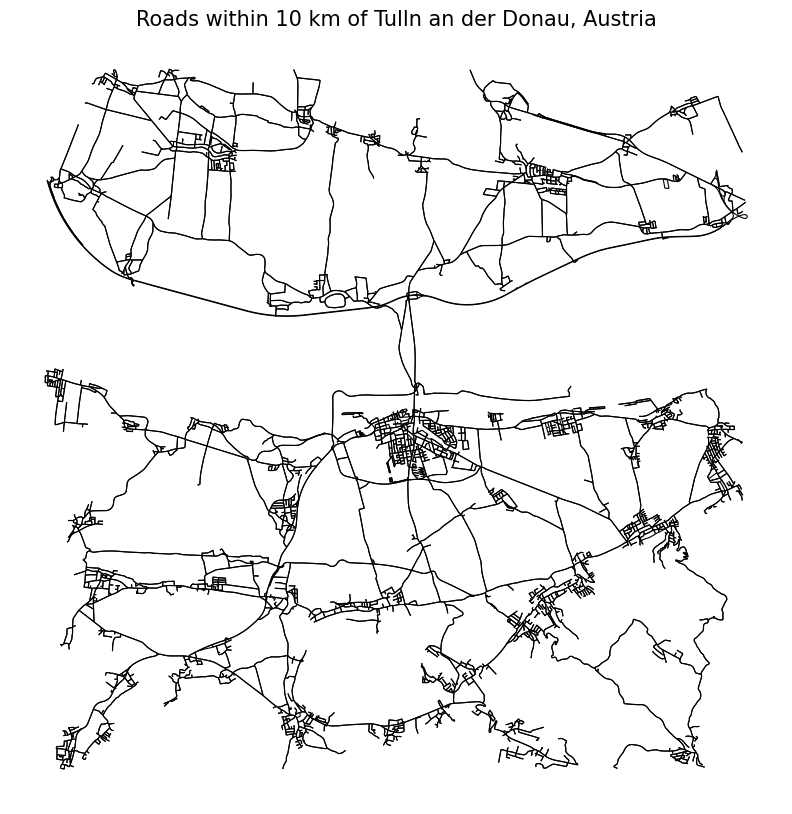

In [8]:
# Geocode the central point
place_name = "Tulln an der Donau, Austria"
point = ox.geocoder.geocode(place_name)

# Set a large distance (e.g., 10 km)
distance = 10000  # in meters

# Download road network within that radius
G = ox.graph_from_point(point, dist=distance, network_type='drive', simplify=True)

# Convert to GeoDataFrame
gdf_edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_edges.plot(ax=ax, linewidth=0.8, color='black')
ax.set_title(f"Roads within {distance/1000:.0f} km of {place_name}", fontsize=15)
plt.axis('off')
plt.show()

## 4.2 Rasterize road 
This step is needed in order to convert vector line data into a **pixel-based format** that aligns with the flood raster, enabling **pixel-wise spatial analysis**. This allows to **compute proximity-based flood risk scores** for road segments using raster operations like distance transforms.

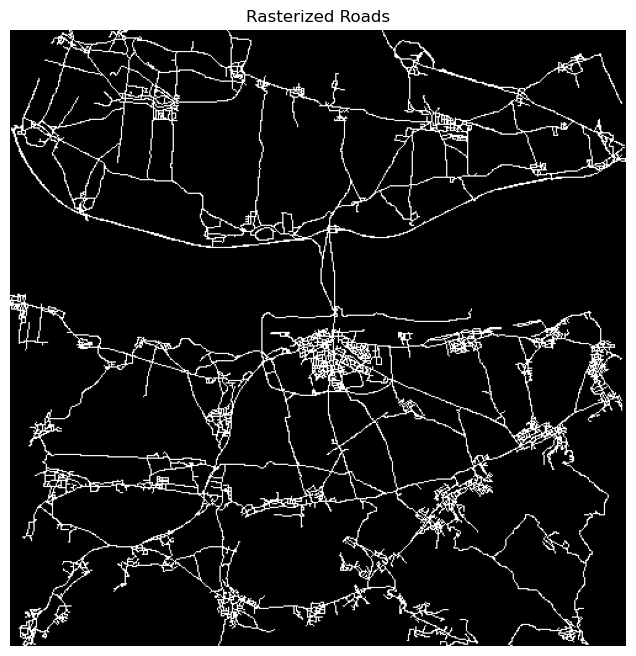

In [9]:
# Define raster size
width = 500  # pixels
height = 500

# Get bounds of your road network
bounds = gdf_edges.total_bounds  # (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bounds

# Define an affine transform
from rasterio.transform import from_bounds
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# Rasterize roads
road_raster = rasterize(
    [(geom, 1) for geom in gdf_edges.geometry],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype=np.uint8
)

plt.figure(figsize=(8, 8))
plt.imshow(road_raster, cmap='gray', origin='upper')
plt.title("Rasterized Roads")
plt.axis('off')
plt.show()

### 4.3. Align flood and road maps
The flood and road maps are aligned to share the same spatial resolution, extent, and coordinate reference system. This ensures accurate pixel-by-pixel analysis, allowing precise measurement of distances between roads and flooded areas for risk assessment.

In [10]:
# Open flood raster
with rasterio.open(most_flooded_file) as src:
    flood_data = src.read(1)
    flood_transform = src.transform
    flood_crs = src.crs

# Prepare an array with the same size as road_raster
flood_aligned = np.zeros_like(road_raster, dtype=np.uint8)

# Reproject/resample to match road raster
reproject(
    source=flood_data,
    destination=flood_aligned,
    src_transform=flood_transform,
    src_crs=flood_crs,
    dst_transform=transform,       # transform from your road raster
    dst_crs=flood_crs,
    resampling=Resampling.nearest
)


(array([[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]], dtype=uint8),
 Affine(0.0005420771999999979, 0.0, 15.9165422,
        0.0, -0.0003593091999999984, 48.4209309))

### 4.3.1 Making sure alignemet is weel done (visual inspection)

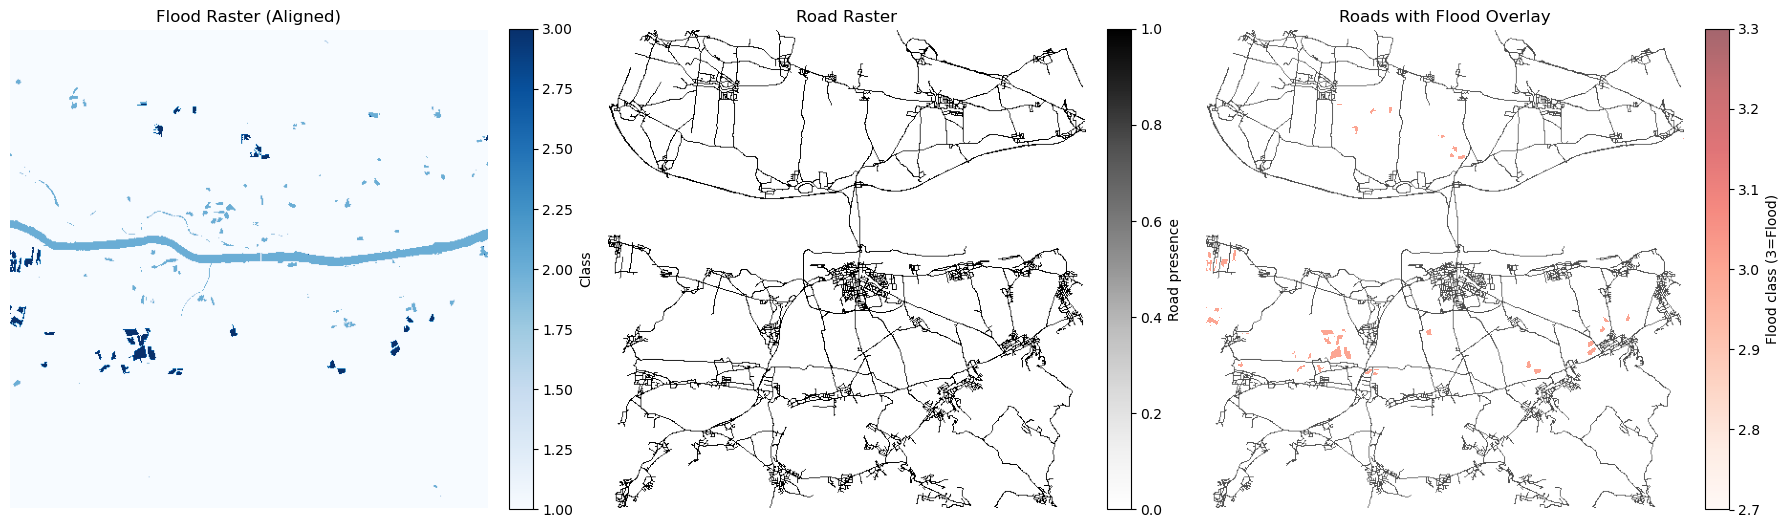

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Create a figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Flood raster
im1 = axes[0].imshow(flood_aligned, cmap='Blues', origin='upper')
axes[0].set_title('Flood Raster (Aligned)')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Class')

# 2. Road raster
im2 = axes[1].imshow(road_raster, cmap='Greys', origin='upper')
axes[1].set_title('Road Raster')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Road presence')

# 3. Roads with Flood overlay
axes[2].imshow(road_raster, cmap='Greys', origin='upper', alpha=0.7)
flood_masked = np.where(flood_aligned == 3, flood_aligned, np.nan)
im3 = axes[2].imshow(flood_masked, cmap='Reds', origin='upper', alpha=0.6)
axes[2].set_title('Roads with Flood Overlay')
axes[2].axis('off')
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04, label='Flood class (3=Flood)')

plt.tight_layout()
plt.show()


### 4.4 Compute distance from each road pixel to nearest flood pixel
* Uses a distance transform on the inverted flood raster (1 = flooded, 0 = no flooded)
* Computing, per each pixel, the **[Euclidean distance Transform (EDT)](https://medium.com/@kareimtarek1972/euclidean-distance-transform-edt-introduction-5d7d7c144aa)** to the **nearest flooded pixel**. In other words, it generates another image, called **distance map**, where each pixel is assigned a numeric value showing the distance to the closest flood pixel.
* The EDT computes the distance from each pixel to the nearest zero-valued pixel. Since flood_aligned == 1 means flooded, so (1 - flood_aligned) makes flooded pixels = 0, so calculating 1-flood_aligned, is a necessary step since EDT computs distance to the nearest zero-valued pixel, and like this it will consider the non-flood pixels distance (non-zero) to the flood pixels (zero)
* The resulting map, an array called **distance_pixels** will show the distance (in pixels) from road pixel to the nearest flood pixel.
![Title](FLOODS/edt_explanation.png)

#### Converting distance (pixels) into real-world distances 
* The **distance_transform_edt** returns distance in pixel units, so now it it's needed to convert them into **real-world** distance, for a meaningful risk assessment. 
* Calculated pixel size is based on spatial bounds and raster dimensions.
* Multiplied pixel distances by average pixel size to get physical distances (degrees).

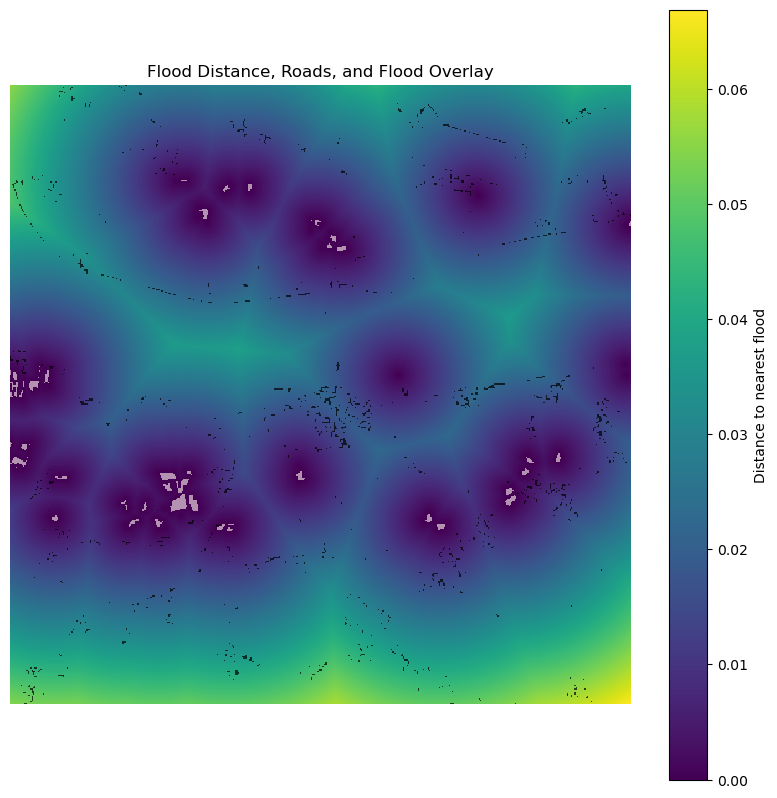

In [12]:
# Creates binary flood mask, with Flood pixels = 3, meaning flood==1,  elsewhere==0
flood_mask = (flood_aligned == 3).astype(np.uint8)   

# Computes distance from non-flood pixels to nearest flood pixel 
# In this case, 1-flood will give 0 which is the distance to which EDT measures
distance_pixels = distance_transform_edt(1 - flood_mask)  

# Convert to meters
pixel_size_x = (maxx - minx) / width
pixel_size_y = (maxy - miny) / height
distance_m = distance_pixels * min(pixel_size_x, pixel_size_y)  

plt.figure(figsize=(10, 10))

# Plot distance map as background
plt.imshow(distance_m, cmap='viridis', origin='upper')
plt.colorbar(label='Distance to nearest flood')
plt.title("Flood Distance, Roads, and Flood Overlay")

# Overlay roads in white
road_mask = road_raster == 1
plt.imshow(np.where(road_mask, 1, np.nan), cmap='gray', origin='upper', alpha=0.7)

# Overlay flood pixels in semi-transparent red
flood_mask = flood_aligned == 3
plt.imshow(np.where(flood_mask, 1, np.nan), cmap='Reds', origin='upper', alpha=0.6)

plt.axis('off')
plt.show()


### 4.5 Computing flood risk score for road pixels
* Assigned a risk score to each road pixel **inversely proportional** to its distance from the nearest flooded pixel
* Risk = 1 / (distance in meters+1)
* Closer roads to flooded zones get higher risk scores, roads farther awat get lower scores.
* Risks scores are normalized: so they range between 0 and 1, highligting **relative flood risk** along the road network.

In [13]:
epsilon = 0.01  # prevent division by zero
# Calculate risk score only for road pixels
risk_score = np.zeros_like(road_raster, dtype=float)

# Inverse distance decay: closer = higher risk
# Adding epsilon prevents division by zero for roads in flooded areas
risk_score[road_mask] = 1 / (distance_m[road_mask] + epsilon)
risk_score[road_mask] /= risk_score[road_mask].max()  # normalize 0-1



## 4.6 See results

### 4.6.1 PNG version

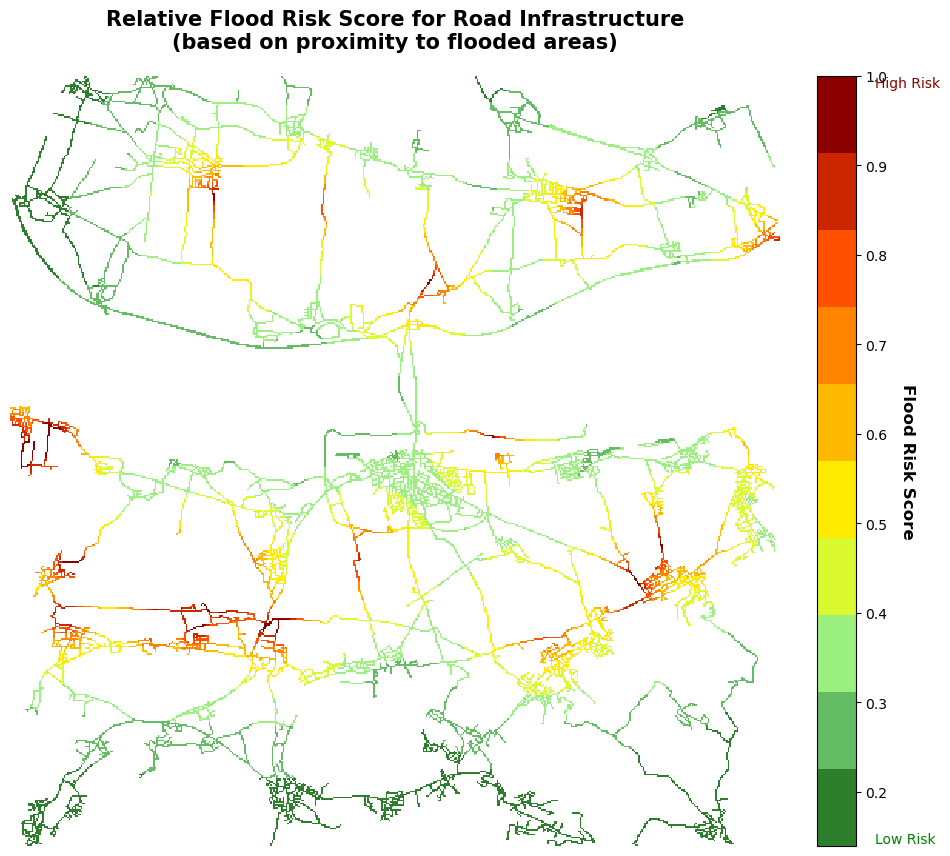

✓ Flood risk map saved to: /home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/Floods Output Results/output/Flood_risk_roads_score_map.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os

# Create a masked array: NaN for non-road pixels
risk_display = np.where(road_raster == 1, risk_score, np.nan)
# Compute actual min and max, ignoring NaN values
vmin = np.nanmin(risk_display)
vmax = np.nanmax(risk_display)


# Create custom colormap: green -> yellow -> orange -> red
colors = ['#2d7f2e', '#90ee90', '#ffff00', '#ffa500', '#ff4500', '#8b0000']
n_bins = 10
cmap = mcolors.LinearSegmentedColormap.from_list('flood_risk', colors, N=n_bins)

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('white')  # White background for non-road areas

# Plot with custom colormap
# Plot using dynamic color stretch
im = ax.imshow(
    risk_display,
    cmap=cmap,
    origin='upper',
    vmin=vmin,
    vmax=vmax,
    interpolation='nearest'
)

# Add colorbar with labels
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Flood Risk Score', fontsize=13, weight='bold')
cbar.ax.set_ylabel('Flood Risk Score', rotation=270, labelpad=20, 
                   fontsize=12, weight='bold')

# Add text labels on colorbar
cbar.ax.text(1.5, 0.0, 'Low Risk', transform=cbar.ax.transAxes, 
             fontsize=10, va='bottom', ha='left', color='green')
cbar.ax.text(1.5, 1.0, 'High Risk', transform=cbar.ax.transAxes, 
             fontsize=10, va='top', ha='left', color='darkred')

ax.set_title("Relative Flood Risk Score for Road Infrastructure\n(based on proximity to flooded areas)", 
             fontsize=15, pad=20, weight='bold')
ax.axis('off')

# Save
output_file = os.path.join(floods_path, "Flood_risk_roads_score_map.png")
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✓ Flood risk map saved to: {output_file}")

### 4.6.2 Visualize on interactive map


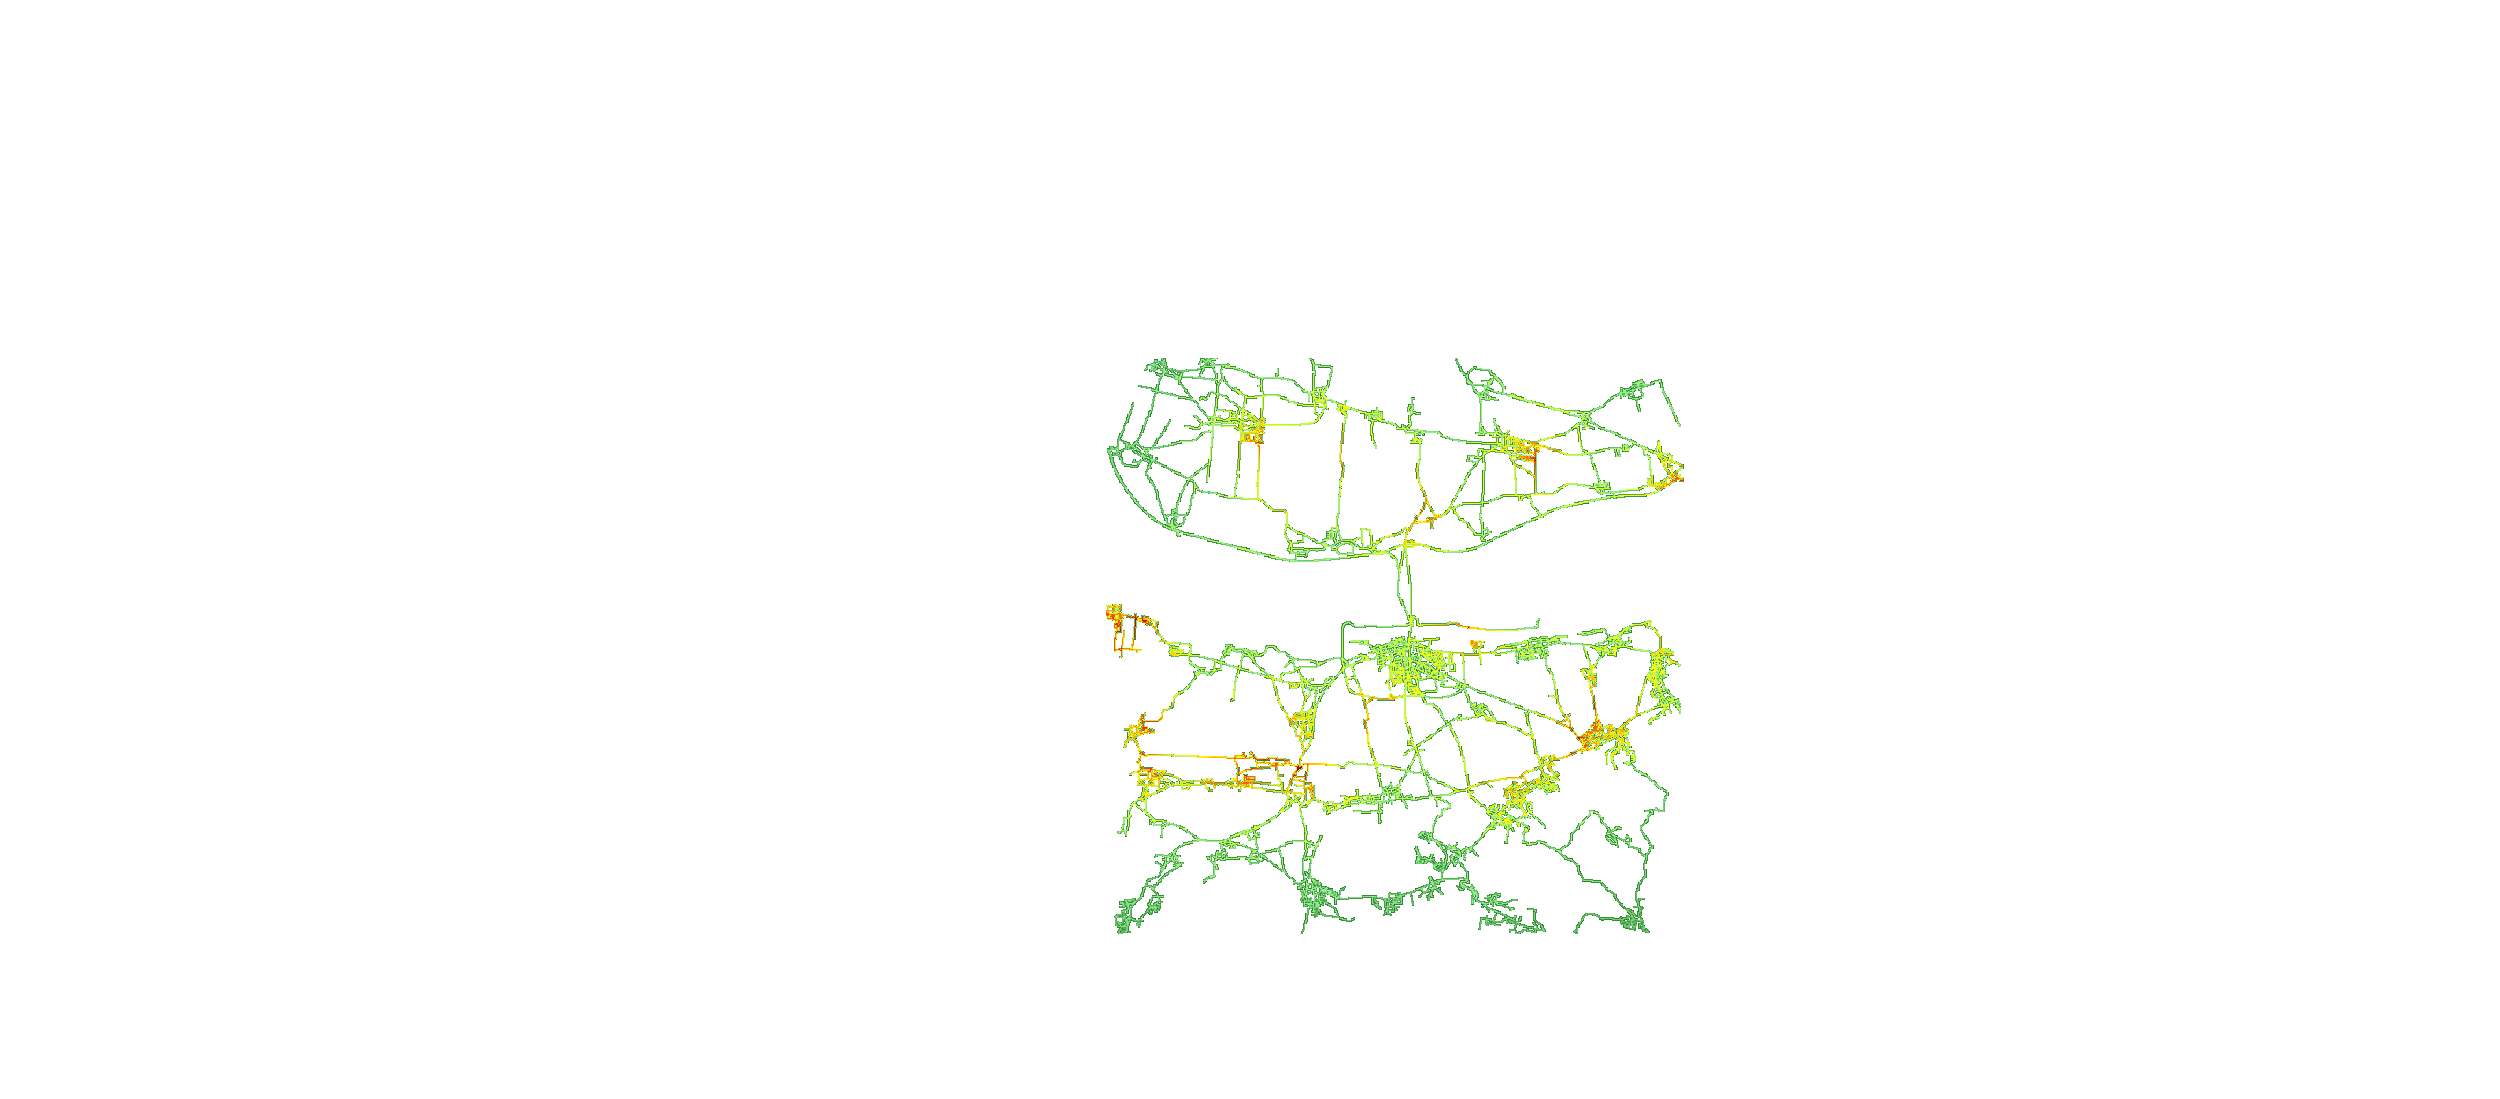

In [15]:
import folium
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling
from matplotlib.colors import LinearSegmentedColormap
import branca.colormap as cm_branca

# Load Sentinel-2 RGB image ---
with rasterio.open(base_tif_path) as src:
    s2_rgb_raw = src.read([1, 2, 3])  # R,G,B bands
    s2_transform = src.transform
    s2_crs = src.crs
    minx, miny, maxx, maxy = src.bounds

# Normalize RGB for display
s2_rgb = np.moveaxis(s2_rgb_raw, 0, -1).astype(np.float32)
s2_rgb -= s2_rgb.min()
s2_rgb /= s2_rgb.max()

# Resample risk_raster to Sentinel-2 size ---
target_shape = s2_rgb.shape[:2]
resampled_risk = np.zeros(target_shape, dtype=np.float32)

reproject(
    source=risk_score,
    destination=resampled_risk,
    src_transform=transform,       # Risk score transform
    src_crs=flood_crs,
    dst_transform=s2_transform,    # S2 transform
    dst_crs=s2_crs,
    resampling=Resampling.bilinear
)

# Recalculate vmin/vmax (same behavior as Matplotlib version)
vmin = np.nanmin(resampled_risk[resampled_risk > 0])
vmax = np.nanmax(resampled_risk)

# Clip and normalize
risk_norm = (resampled_risk - vmin) / (vmax - vmin)
risk_norm = np.clip(risk_norm, 0, 1)

# CUSTOM COLORMAP (same as Matplotlib version) ---
colors = ['#2d7f2e', '#90ee90', '#ffff00', 
          '#ffa500', '#ff4500', '#8b0000']
cmap = LinearSegmentedColormap.from_list("flood_risk", colors, N=256)

# Convert normalized risk to RGBA image
risk_rgba = (cmap(risk_norm) * 255).astype(np.uint8)

# Make 0-risk transparent (same as your Matplotlib map)
risk_rgba[resampled_risk == 0, 3] = 0

# Create Folium Map ---
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

bounds = [[miny, minx], [maxy, maxx]]

# Add flood risk overlay
folium.raster_layers.ImageOverlay(
    image=risk_rgba,
    bounds=bounds,
    opacity=0.75,
    name="Flood Risk Score"
).add_to(m)

# --- 5. Add custom colormap legend in Folium ---

colormap = cm_branca.LinearColormap(
    colors=colors,
    vmin=vmin,
    vmax=vmax,
    caption="Flood Risk Score"
)

# Custom legend appearance
colormap_style = """
<style>
.branca-colormap {
    width: 350px !important;
    height: 50px !important;
    font-size: 15px !important;
    font-weight: bold !important;
}
.branca-colormap .caption {
    font-size: 16px !important;
    font-weight: bold !important;
}
</style>
"""

m.get_root().header.add_child(folium.Element(colormap_style))
colormap.add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Show map (Jupyter)
m


### 4.6.3 Aditional statistics

=== Risk Score Statistics (Roads Only) ===
Number of road pixels: 20063
Min risk score: 0.139540
Max risk score: 1.000000
Mean risk score: 0.407749
Median risk score: 0.371445
Std dev: 0.173498

=== Roads by Risk Category ===
Very Low Risk (0.0-0.2): 1788 pixels (8.9%)
Low Risk (0.2-0.4): 9871 pixels (49.2%)
Medium Risk (0.4-0.6): 5526 pixels (27.5%)
High Risk (0.6-0.8): 2125 pixels (10.6%)
Very High Risk (0.8-1.0): 753 pixels (3.8%)


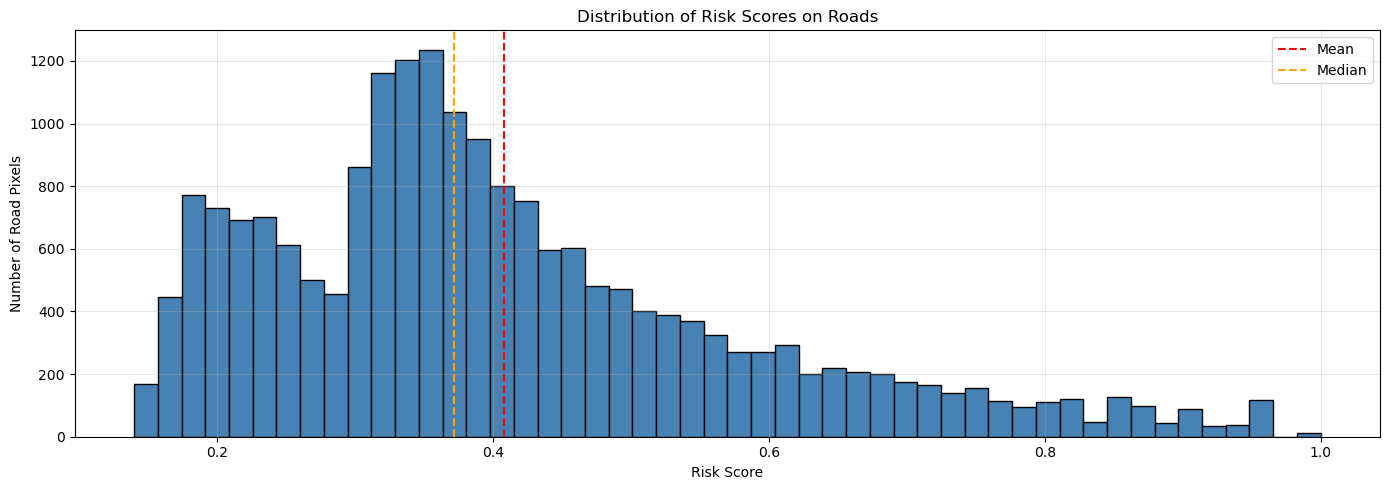

✓ Histogram saved to: /home/7524d4be-a344-408f-b679-3694718f8fed/team-extra/WASDI/Floods Output Results/output/Distribution_of_Risk_Scores_on_Roads.png


In [16]:
import numpy as np

# Check the actual distribution of risk scores on roads
road_mask = road_raster == 1
road_risk_values = risk_score[road_mask]

print("=== Risk Score Statistics (Roads Only) ===")
print(f"Number of road pixels: {road_mask.sum()}")
print(f"Min risk score: {road_risk_values.min():.6f}")
print(f"Max risk score: {road_risk_values.max():.6f}")
print(f"Mean risk score: {road_risk_values.mean():.6f}")
print(f"Median risk score: {np.median(road_risk_values):.6f}")
print(f"Std dev: {road_risk_values.std():.6f}")



# Count roads in different risk categories
print("\n=== Roads by Risk Category ===")
very_low = (road_risk_values < 0.2).sum()
low = ((road_risk_values >= 0.2) & (road_risk_values < 0.4)).sum()
medium = ((road_risk_values >= 0.4) & (road_risk_values < 0.6)).sum()
high = ((road_risk_values >= 0.6) & (road_risk_values < 0.8)).sum()
very_high = (road_risk_values >= 0.8).sum()

total = len(road_risk_values)

print(f"Very Low Risk (0.0-0.2): {very_low} pixels ({very_low/total*100:.1f}%)")
print(f"Low Risk (0.2-0.4): {low} pixels ({low/total*100:.1f}%)")
print(f"Medium Risk (0.4-0.6): {medium} pixels ({medium/total*100:.1f}%)")
print(f"High Risk (0.6-0.8): {high} pixels ({high/total*100:.1f}%)")
print(f"Very High Risk (0.8-1.0): {very_high} pixels ({very_high/total*100:.1f}%)")


# 5. Visualize the two histograms only
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Histogram of risk scores
axes.hist(road_risk_values, bins=50, color='steelblue', edgecolor='black')
axes.set_xlabel('Risk Score')
axes.set_ylabel('Number of Road Pixels')
axes.set_title('Distribution of Risk Scores on Roads')
axes.axvline(road_risk_values.mean(), color='red', linestyle='--', label='Mean')
axes.axvline(np.median(road_risk_values), color='orange', linestyle='--', label='Median')
axes.legend()
axes.grid(alpha=0.3)



plt.tight_layout()

# --- Save figure in the same location as the previous flood risk map ---
histogram_file = os.path.join(floods_path, "Distribution_of_Risk_Scores_on_Roads.png")
plt.savefig(histogram_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✓ Histogram saved to: {histogram_file}")


In [ ]:
# Verify flood extent
print(f"\n=== Flood Data Check ===")
print(f"Flooded pixels: {(flood_aligned == 1).sum()}")
print(f"Total pixels: {flood_aligned.size}")
print(f"Flood coverage: {(flood_aligned == 1).sum()/flood_aligned.size*100:.2f}%")

# Visualize flood and roads together
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(flood_aligned, cmap='Blues', origin='upper')
axes[0].set_title('Flooded Areas')
axes[0].axis('off')

axes[1].imshow(road_raster, cmap='Greys', origin='upper')
axes[1].set_title('Roads')
axes[1].axis('off')

# Overlay
overlay = np.zeros((*flood_aligned.shape, 3))
overlay[flood_aligned == 1] = [0, 0, 1]  # Blue for flood
overlay[road_raster == 1] = [1, 0, 0]  # Red for roads
overlay[(flood_aligned == 1) & (road_raster == 1)] = [1, 0, 1]  # Purple for overlap

axes[2].imshow(overlay, origin='upper')
axes[2].set_title('Overlay (Blue=Flood, Red=Roads, Purple=Both)')
axes[2].axis('off')

plt.tight_layout()
plt.show()